In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Features:
- Price Ratio: ClosePrice / OriginalListPrice
    - Measures negotiation strength
- Price Per Sq Ft: ClosePrice / LivingArea
    - Normalizes price across sizes
- Days on Market: DaysonMarket (raw field)
    - Time-to-sell indicator
- Year / Month / YrMo: Derived from CloseDate
    - Enables time-series analysis
- Close to Original List Ratio: ClosePrice / OriginalListPrice
    - Captures full price reduction history
- Listing to Contract Days: PurchaseContractDate - ListingContractDate
    - Measures time from listing to accepted offer
- Contract to Close Days: CloseDate - PurchaseContractDate
    - Escrow and closing period duration

In [40]:
listings_cleaned_df = pd.read_csv("../data/Listing/listings_cleaned.csv")
listings_cleaned_df.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,YearBuilt_Missing,MainLevelBedrooms_Missing,Stories_Missing,GarageSpaces_Missing,ClosePrice_Missing,No_Purchase_Date,No_Close_Date,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,0,1,0,0,1,True,True,False,False,False
1,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,0,1,0,1,1,False,True,False,False,False
2,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0,0,0,0,1,True,True,False,False,False
3,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,0,1,0,0,1,True,True,False,False,False
4,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,0,0,1,0,1,True,True,False,False,False


In [41]:
listings_cleaned_df['price_ratio'] = listings_cleaned_df['ClosePrice'] / listings_cleaned_df['OriginalListPrice']
listings_cleaned_df[listings_cleaned_df['price_ratio'].notna()].head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms_Missing,Stories_Missing,GarageSpaces_Missing,ClosePrice_Missing,No_Purchase_Date,No_Close_Date,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio
10,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,0,0,0,0,False,False,False,False,False,1.010135
17,650000.0,1073219502,lorijo@tcsn.net,2024-03-15,650000.0,Lori Jo,Stribling,35.508840,-120.690614,5405 San Benito Road,...,0,0,0,0,False,False,False,False,False,1.000000
21,1025000.0,1073169832,doug@socalmodern.com,2024-05-02,962500.0,Douglas,Kramer,33.812886,-118.097004,3108 Kallin Avenue,...,0,0,0,0,False,False,False,False,False,0.939024
23,725000.0,1073164974,zachmickelson1@gmail.com,2024-04-30,725000.0,Zachary,Mickelson,33.740706,-117.888816,505 S Spruce Street,...,0,0,0,0,False,False,False,False,False,1.000000
46,730000.0,1071104851,Antonio@AntonioMatier.com,2024-04-09,730000.0,Antonio,Matier,NaN,NaN,2456 Havenscourt Blvd,...,1,1,0,0,False,False,False,False,False,1.000000


In [42]:
listings_cleaned_df.shape

(819760, 64)

In [43]:
listings_cleaned_df['price_per_sqft'] = listings_cleaned_df['ClosePrice'] / listings_cleaned_df['LivingArea']
listings_cleaned_df[listings_cleaned_df['price_per_sqft'].notna()].head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,Stories_Missing,GarageSpaces_Missing,ClosePrice_Missing,No_Purchase_Date,No_Close_Date,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft
10,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,0,0,0,False,False,False,False,False,1.010135,664.852554
17,650000.0,1073219502,lorijo@tcsn.net,2024-03-15,650000.0,Lori Jo,Stribling,35.508840,-120.690614,5405 San Benito Road,...,0,0,0,False,False,False,False,False,1.000000,464.285714
21,1025000.0,1073169832,doug@socalmodern.com,2024-05-02,962500.0,Douglas,Kramer,33.812886,-118.097004,3108 Kallin Avenue,...,0,0,0,False,False,False,False,False,0.939024,851.769912
23,725000.0,1073164974,zachmickelson1@gmail.com,2024-04-30,725000.0,Zachary,Mickelson,33.740706,-117.888816,505 S Spruce Street,...,0,0,0,False,False,False,False,False,1.000000,580.000000
46,730000.0,1071104851,Antonio@AntonioMatier.com,2024-04-09,730000.0,Antonio,Matier,NaN,NaN,2456 Havenscourt Blvd,...,1,0,0,False,False,False,False,False,1.000000,576.619273


In [44]:
listings_cleaned_df['price_per_sqft'].isna().sum()

np.int64(591486)

In [45]:
listings_cleaned_df[listings_cleaned_df['CloseDate'].notna()]['CloseDate'].head()

10    2024-05-01
17    2024-03-15
21    2024-05-02
23    2024-04-30
46    2024-04-09
Name: CloseDate, dtype: str

In [46]:
listings_cleaned_df['CloseDate'] = pd.to_datetime(listings_cleaned_df['CloseDate'])

In [47]:
listings_cleaned_df['Month'] = listings_cleaned_df['CloseDate'].dt.month

In [48]:
listings_cleaned_df['Month'].isna().sum()

np.int64(568819)

In [49]:
listings_cleaned_df['Year'] = listings_cleaned_df['CloseDate'].dt.year

In [50]:
listings_cleaned_df['Year'].isna().sum()

np.int64(568819)

In [51]:
listings_cleaned_df['CloseDate'].isna().sum()

np.int64(568819)

In [52]:
listings_cleaned_df['YrMo'] = listings_cleaned_df['CloseDate'].dt.to_period('M')

In [53]:
listings_cleaned_df['YrMo'].isna().sum()

np.int64(568819)

In [54]:
listings_cleaned_df[listings_cleaned_df['YrMo'].notna()]['YrMo'].head()

10    2024-05
17    2024-03
21    2024-05
23    2024-04
46    2024-04
Name: YrMo, dtype: period[M]

In [55]:
listings_cleaned_df['CloseToOriginalListRatio'] = listings_cleaned_df['ClosePrice'] / listings_cleaned_df['OriginalListPrice']

In [56]:
listings_cleaned_df['CloseToOriginalListRatio'].isna().sum()

np.int64(591486)

In [57]:
listings_cleaned_df['PurchaseContractDate'] = pd.to_datetime(listings_cleaned_df['PurchaseContractDate'])

In [58]:
listings_cleaned_df['ListingContractDate'] = pd.to_datetime(listings_cleaned_df['ListingContractDate'])

In [59]:
listings_cleaned_df['ListingToContractDays'] = listings_cleaned_df['PurchaseContractDate'] - listings_cleaned_df['ListingContractDate']

In [60]:
listings_cleaned_df['ListingToContractDays'].isna().sum()

np.int64(453293)

In [61]:
listings_cleaned_df[listings_cleaned_df['ListingToContractDays'].notna()]['ListingToContractDays'].head()

1    127 days
9    104 days
10    20 days
11   114 days
15   101 days
Name: ListingToContractDays, dtype: timedelta64[us]

In [62]:
listings_cleaned_df['ContractToCloseDays'] = listings_cleaned_df['CloseDate'] - listings_cleaned_df['PurchaseContractDate']

In [63]:
listings_cleaned_df[listings_cleaned_df['ContractToCloseDays'].notna()]['ContractToCloseDays'].head()

10   73 days
17   43 days
21    2 days
23   81 days
46   58 days
Name: ContractToCloseDays, dtype: timedelta64[us]

In [64]:
listings_cleaned_df['ContractToCloseDays'].isna().sum()

np.int64(575035)

#### **Segment Analysis**

Property Segmentation

In [65]:
property_summary = (
    listings_cleaned_df.groupby(['PropertyType', 'PropertySubType'])
    .agg(
        sales_count=('ClosePrice', 'count'),
        median_close_price=('ClosePrice', 'median'),
        avg_close_price=('ClosePrice', 'mean'),
        avg_price_per_sqft=('price_per_sqft', 'mean'),
        median_dom=('DaysOnMarket', 'median'),
        avg_sale_to_list=('price_ratio', 'mean')
    )
    .reset_index()
)

A. Market Heat Score
- Higher measures mean stronger demand and faster movement

In [66]:
property_summary['market_heat_score'] = (property_summary['avg_sale_to_list'] / property_summary['median_dom'])

In [67]:
property_summary[property_summary['market_heat_score'] != float('inf')]['market_heat_score'].describe()

count    70.000000
mean      2.337394
std      11.450252
min       0.069561
25%       0.122256
50%       0.161789
75%       0.316115
max      72.541506
Name: market_heat_score, dtype: float64

In [68]:
property_summary[property_summary['market_heat_score'] > 72]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score
27,CommercialSale,UnimprovedLand,1,86000.0,8.600000e+04,53.750000,0.0,0.868687,inf
51,Residential,SingleFamilyResidence,105762,925000.0,1.286321e+06,inf,10.0,inf,inf
62,ResidentialIncome,Duplex,1368,920500.0,1.073107e+06,645.759055,10.0,725.415059,72.541506
84,ResidentialLease,SingleFamilyResidence,37439,4300.0,9.971033e+03,inf,9.0,inf,inf


In [69]:
property_summary[property_summary['market_heat_score'] < 0.07]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score
48,Residential,MobileHome,25,450000.0,433100.0,inf,13.0,0.904294,0.069561


B. Premium vs. Discount
- Shows whether homes sell above or below asking. 
- Ex: 
    - +3% -> bidding wars
    - -5% -> price negotiation pressure

In [70]:
property_summary['premium_discount_pct'] = ((property_summary['avg_sale_to_list'] - 1) * 100)

In [71]:
property_summary[property_summary['premium_discount_pct'] < 0].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
1,BusinessOpportunity,SingleFamilyResidence,22,130000.0,449277.272727,280.798295,6.0,0.782358,0.130393,-21.764180
3,CommercialLease,Business,6,3025.0,3136.833333,1.960521,6.0,0.931481,0.155247,-6.851941
5,CommercialLease,Industrial,10,3147.6,3868.820000,2.418013,1.0,0.857741,0.857741,-14.225867
6,CommercialLease,MixedUse,26,2875.0,3139.730769,1.962332,1.0,0.978934,0.978934,-2.106610
12,CommercialLease,Warehouse,5,5000.0,7258.962000,4.536851,1.0,0.957244,0.957244,-4.275566


In [72]:
property_summary.groupby('PropertyType')['premium_discount_pct'].mean()

PropertyType
BusinessOpportunity     -21.764180
CommercialLease         886.523374
CommercialSale            1.067321
Land                     21.372000
ManufacturedInPark       16.061343
Residential                    inf
ResidentialIncome      7240.973989
ResidentialLease               inf
Name: premium_discount_pct, dtype: float64

In [73]:
property_summary.nsmallest(1, 'premium_discount_pct')

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
1,BusinessOpportunity,SingleFamilyResidence,22,130000.0,449277.272727,280.798295,6.0,0.782358,0.130393,-21.76418


In [74]:
property_summary[property_summary['premium_discount_pct'] > 0].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
7,CommercialLease,Office,36,2200.0,2.512300e+04,15.701874,1.0,6.679403,6.679403,567.940336
8,CommercialLease,Retail,37,2650.0,2.832380e+04,17.702373,1.0,64.073580,64.073580,6307.358035
9,CommercialLease,SingleFamilyResidence,97,2950.0,3.601013e+04,22.495118,5.0,3.443486,0.688697,244.348600
19,CommercialSale,MixedUse,113,2175000.0,3.699048e+06,2311.904972,4.0,1.757271,0.439318,75.727102
32,Land,SingleFamilyResidence,1394,400000.0,8.544465e+05,534.029038,8.0,1.695939,0.211992,69.593870


In [75]:
property_summary.nlargest(1, 'premium_discount_pct')

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
51,Residential,SingleFamilyResidence,105762,925000.0,1.286321e+06,inf,10.0,inf,inf,inf


C. Relative Liquity Score
- Lower DOM = more liquid market

In [76]:
property_summary['liquidity_score'] = (
    1 / property_summary['median_dom']
)

In [77]:
property_summary['liquidity_score'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    90.000000
mean           inf
std            NaN
min       0.034483
25%       0.100000
50%       0.142857
75%       0.321429
max            inf
Name: liquidity_score, dtype: float64

In [78]:
max_liquidity = property_summary[property_summary['liquidity_score'] != float('inf')]['liquidity_score'].max()
max_liquidity

np.float64(2.0)

In [79]:
property_summary[property_summary['liquidity_score'] == max_liquidity]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
2,CommercialLease,Agriculture,0,NaN,NaN,NaN,0.5,NaN,NaN,NaN,2.0
77,ResidentialLease,ManufacturedHome,10,1700.0,1820.0,1.695693,0.5,0.958333,1.916667,-4.166667,2.0


Commerical Lease and Residential Lease houses tend to sell faster

In [80]:
min_liquidity = property_summary['liquidity_score'].min()
min_liquidity

np.float64(0.034482758620689655)

In [81]:
property_summary[property_summary['liquidity_score'] == min_liquidity]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
61,ResidentialIncome,DeededParking,0,NaN,NaN,NaN,29.0,NaN,NaN,NaN,0.034483


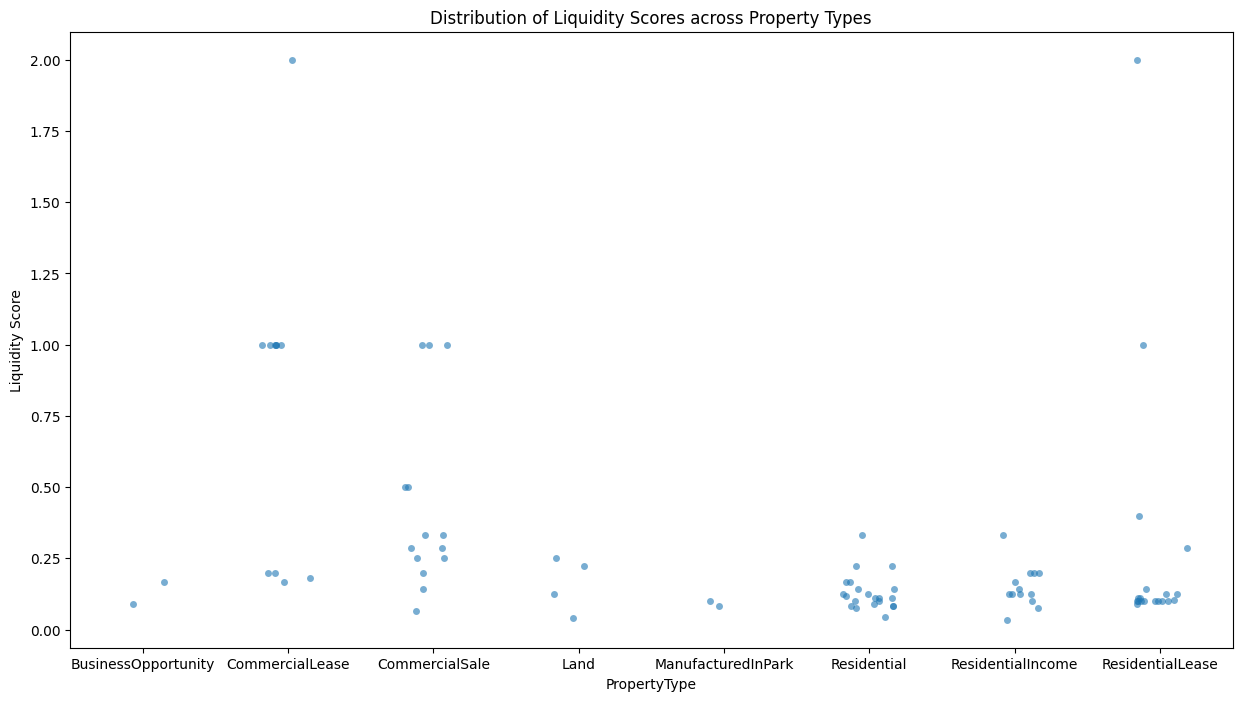

In [82]:
plt.figure(figsize=(15, 8))

sns.stripplot(
    x="PropertyType",
    y="liquidity_score",
    data=property_summary,
    jitter=0.2, 
    alpha=0.6,
)

plt.title("Distribution of Liquidity Scores across Property Types")
plt.ylabel("Liquidity Score")
plt.show()

Most Expensive

In [83]:
expensive_segments = property_summary.sort_values(
    by='median_close_price',
    ascending=False
)
expensive_segments.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
43,Residential,Farm,2,2450000.0,2.450000e+06,819.292155,6.0,0.909713,0.151619,-9.028673,0.166667
28,CommercialSale,Warehouse,7,2250000.0,2.447714e+06,1529.821429,3.0,0.978585,0.326195,-2.141543,0.333333
19,CommercialSale,MixedUse,113,2175000.0,3.699048e+06,2311.904972,4.0,1.757271,0.439318,75.727102,0.250000
21,CommercialSale,MultiFamily,20,2065000.0,2.089400e+06,1305.875000,3.0,0.920778,0.306926,-7.922187,0.333333
57,ResidentialIncome,Apartment,385,1825000.0,2.370329e+06,1481.455914,5.0,0.970582,0.194116,-2.941837,0.200000


Fastest Selling

In [84]:
faster_segments = property_summary.sort_values(
    by='median_dom',
    ascending=False
)
faster_segments.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
61,ResidentialIncome,DeededParking,0,NaN,NaN,NaN,29.0,NaN,NaN,NaN,0.034483
31,Land,CoOwnership,0,NaN,NaN,NaN,25.0,NaN,NaN,NaN,0.040000
36,Residential,Apartment,0,NaN,NaN,NaN,23.0,NaN,NaN,NaN,0.043478
13,CommercialSale,Agriculture,0,NaN,NaN,NaN,15.5,NaN,NaN,NaN,0.064516
48,Residential,MobileHome,25,450000.0,433100.0,inf,13.0,0.904294,0.069561,-9.570621,0.076923


In [85]:
def classify_market(row):

    if row['market_heat_score'] > 0.02:
        return 'Hot Market'

    elif row['market_heat_score'] > 0.01:
        return 'Balanced'

    else:
        return 'Slow Market'

property_summary['market_category'] = (
    property_summary.apply(classify_market, axis=1)
)

In [86]:
property_summary['market_category'].value_counts()

market_category
Hot Market     73
Slow Market    17
Name: count, dtype: int64

In [87]:
hot_market = property_summary[property_summary['market_category'] == "Hot Market"]
hot_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
1,BusinessOpportunity,SingleFamilyResidence,22,130000.0,449277.272727,280.798295,6.0,0.782358,0.130393,-21.764180,0.166667,Hot Market
3,CommercialLease,Business,6,3025.0,3136.833333,1.960521,6.0,0.931481,0.155247,-6.851941,0.166667,Hot Market
5,CommercialLease,Industrial,10,3147.6,3868.820000,2.418013,1.0,0.857741,0.857741,-14.225867,1.000000,Hot Market
6,CommercialLease,MixedUse,26,2875.0,3139.730769,1.962332,1.0,0.978934,0.978934,-2.106610,1.000000,Hot Market
7,CommercialLease,Office,36,2200.0,25122.998889,15.701874,1.0,6.679403,6.679403,567.940336,1.000000,Hot Market


In [88]:
hot_market.describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encou

,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,73.000000,7.300000e+01,7.300000e+01,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,3127.041096,5.637737e+05,6.949057e+05,inf,6.568493,inf,inf,inf,inf
std,13454.128531,6.492094e+05,8.039472e+05,NaN,3.469425,NaN,NaN,NaN,NaN
min,1.000000,1.300000e+03,1.489012e+03,1.073066,0.000000,0.782358,0.069561,-21.764180,0.076923
25%,9.000000,3.025000e+03,4.987647e+03,15.701874,4.000000,0.947566,0.124887,-5.243352,0.100000
50%,36.000000,3.250000e+05,4.000095e+05,518.542114,7.000000,0.984154,0.185139,-1.584621,0.142857
75%,437.000000,9.250000e+05,1.254428e+06,1051.264205,10.000000,1.265876,0.389167,26.587641,0.250000
max,105762.000000,2.450000e+06,3.699048e+06,inf,13.000000,inf,inf,inf,inf


In [89]:
slow_market = property_summary[property_summary['market_category'] == "Slow Market"]
slow_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
0,BusinessOpportunity,MixedUse,0,NaN,NaN,NaN,11.0,NaN,NaN,NaN,0.090909,Slow Market
2,CommercialLease,Agriculture,0,NaN,NaN,NaN,0.5,NaN,NaN,NaN,2.000000,Slow Market
4,CommercialLease,Farm,0,NaN,NaN,NaN,5.5,NaN,NaN,NaN,0.181818,Slow Market
11,CommercialLease,UnimprovedLand,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.000000,Slow Market
13,CommercialSale,Agriculture,0,NaN,NaN,NaN,15.5,NaN,NaN,NaN,0.064516,Slow Market


In [90]:
slow_market.describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,17.0,0.0,0.0,0.0,17.000000,0.0,0.0,0.0,17.000000
mean,0.0,NaN,NaN,NaN,8.294118,NaN,NaN,NaN,inf
std,0.0,NaN,NaN,NaN,9.622660,NaN,NaN,NaN,NaN
min,0.0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.034483
25%,0.0,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.076923
50%,0.0,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.250000
75%,0.0,NaN,NaN,NaN,13.000000,NaN,NaN,NaN,1.000000
max,0.0,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,inf


In [91]:
# Group by property type, calculate the median of the close price, and find the maximum value
max_mean_price = property_summary.groupby('PropertyType')['avg_close_price'].max()
max_mean_price.sort_values(ascending=False)

PropertyType
CommercialSale         3.699048e+06
Residential            2.450000e+06
ResidentialIncome      2.370329e+06
Land                   8.544465e+05
BusinessOpportunity    4.492773e+05
ManufacturedInPark     2.509149e+05
CommercialLease        3.601013e+04
ResidentialLease       9.971033e+03
Name: avg_close_price, dtype: float64

In [92]:
# Group by property type, calculate the median of the close price, and find the maximum value
max_median_price = property_summary.groupby('PropertyType')['median_close_price'].max()
max_median_price.sort_values(ascending=False).head()

PropertyType
Residential           2450000.0
CommercialSale        2250000.0
ResidentialIncome     1825000.0
Land                   699000.0
ManufacturedInPark     240000.0
Name: median_close_price, dtype: float64

In [93]:
max_sales = property_summary.groupby('PropertyType')['sales_count'].max()
max_sales.sort_values(ascending=False)

PropertyType
Residential            105762
ResidentialLease        37439
ManufacturedInPark       4155
ResidentialIncome        1621
Land                     1394
CommercialSale            253
CommercialLease            97
BusinessOpportunity        22
Name: sales_count, dtype: int64

In [94]:
# Group by property subtype, calculate the mean of the close price, and find the maximum value
max_mean_price = property_summary.groupby('PropertySubType')['avg_close_price'].max()
max_mean_price.sort_values(ascending=False).head()

PropertySubType
MixedUse                 3.699048e+06
Farm                     2.450000e+06
Warehouse                2.447714e+06
Apartment                2.370329e+06
SingleFamilyResidence    2.153609e+06
Name: avg_close_price, dtype: float64

In [95]:
# Group by property subtype, calculate the median of the close price, and find the maximum value
max_median_price = property_summary.groupby('PropertySubType')['median_close_price'].max()
max_median_price.sort_values(ascending=False).head()

PropertySubType
Farm           2450000.0
Warehouse      2250000.0
MixedUse       2175000.0
MultiFamily    2065000.0
Apartment      1825000.0
Name: median_close_price, dtype: float64

In [96]:
max_sales = property_summary.groupby('PropertySubType')['sales_count'].max()
max_sales.sort_values(ascending=False).head()

PropertySubType
SingleFamilyResidence    105762
Condominium               22895
Townhouse                  8540
Apartment                  6965
Duplex                     2633
Name: sales_count, dtype: int64

Geographic Segmentation

In [97]:
geo_summary = (
    listings_cleaned_df.groupby(['CountyOrParish', 'MLSAreaMajor'])
    .agg(
        transactions=('ListingId', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('price_per_sqft', 'median'),
        median_dom=('DaysOnMarket', 'median'),
        avg_sale_to_list=('price_ratio', 'mean'),
        avg_price_per_sqft = ('price_per_sqft', 'mean')
    )
    .reset_index()
)

In [98]:
geo_summary[geo_summary.notna()].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft
0,Alameda,699 - Not Defined,3819,1076000.0,706.003356,12.0,1.035579,702.856905
1,Alameda,BERK - Berkeley,11,76675.0,182.564622,14.0,0.992647,182.564622
2,Alameda,GLV - Glenview,2,NaN,NaN,14.0,NaN,NaN
3,Alameda,Missing,28826,1100000.0,690.318302,11.0,115.681860,inf
4,Alameda,VTU - Ventura,2,NaN,NaN,18.0,NaN,NaN


In [99]:
max_transactions = geo_summary.groupby('CountyOrParish')['transactions'].max()
max_transactions.sort_values(ascending=False).head()

CountyOrParish
Riverside       31264
Alameda         28826
Contra Costa    28769
Santa Clara     28452
San Mateo       11041
Name: transactions, dtype: int64

In [100]:
avg_transactions = geo_summary.groupby('CountyOrParish')['transactions'].mean()
avg_transactions.sort_values(ascending=False).head()

CountyOrParish
Alameda         6532.000000
Santa Clara     5133.833333
Contra Costa    5018.666667
San Mateo       2952.750000
Butte           1601.000000
Name: transactions, dtype: float64

In [101]:
max_transactions = geo_summary.groupby('MLSAreaMajor')['transactions'].max()
max_transactions.sort_values(ascending=False).head()

MLSAreaMajor
SRCAR - Southwest Riverside County    31264
Missing                               28826
699 - Not Defined                     28452
252 - Riverside                        8433
C14 - Santa Monica                     5797
Name: transactions, dtype: int64

In [102]:
avg_transactions = geo_summary.groupby('MLSAreaMajor')['transactions'].mean()
avg_transactions.sort_values(ascending=False).head()

MLSAreaMajor
SRCAR - Southwest Riverside County    10430.333333
VIC - Victorville                      4736.000000
313 - La Quinta South of HWY 111       4383.000000
252 - Riverside                        4218.000000
SO - Sherman Oaks                      4135.000000
Name: transactions, dtype: float64

A. Market Heat Score

In [103]:
geo_summary['market_heat_score'] = (
    geo_summary['avg_sale_to_list'] / geo_summary['median_dom']
)

In [104]:
geo_summary[geo_summary['market_heat_score'] != float('inf')]['market_heat_score'].describe()

count    1232.000000
mean        3.069826
std        60.230603
min         0.004449
25%         0.089686
50%         0.106975
75%         0.127097
max      1666.760030
Name: market_heat_score, dtype: float64

In [105]:
geo_summary[geo_summary['market_heat_score'] > 1660]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score
123,Kern,RCR - Ridgecrest,169,205700.0,156.790771,9.0,inf,120.823490,inf
727,Orange,C42 - Downtown L.A.,1,2890.0,4.425727,0.0,1.000000e+00,4.425727,inf
801,Orange,RVB - Riverbend,98,763750.0,453.484398,12.5,2.083450e+04,303.592758,1666.76003
845,Other,634 - La Canada Flintridge,3,1400000.0,875.000000,0.0,1.272727e+00,875.000000,inf
955,Riverside,242 - Lake Elsinore Northeast,6,2150.0,2.488426,0.0,1.000000e+00,2.488426,inf
1064,San Bernardino,264 - Fontana,4080,570000.0,321.276671,11.0,inf,260.264676,inf


In [106]:
geo_summary[geo_summary['market_heat_score'] < 0.005]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score
1430,Stanislaus,MP6 - Mariposa 6,1,40000.0,46.189376,58.0,0.258065,46.189376,0.004449


B. Affordability

In [107]:
max_sqft = geo_summary.groupby('CountyOrParish')['avg_price_per_sqft'].max()
max_sqft[max_sqft != float('inf')].sort_values(ascending=False).head()

CountyOrParish
Monterey       3104.212860
Other          2756.250000
Orange         2571.906862
Mendocino      2435.908934
Santa Clara    1136.363636
Name: avg_price_per_sqft, dtype: float64

In [108]:
min_sqft = geo_summary.groupby('CountyOrParish')['avg_price_per_sqft'].min()
min_sqft.sort_values(ascending=True).head()

CountyOrParish
Other             0.000937
Other County      1.031250
Orange            1.347040
Riverside         1.437651
San Bernardino    1.619138
Name: avg_price_per_sqft, dtype: float64

In [109]:
max_sqft = geo_summary.groupby('MLSAreaMajor')['avg_price_per_sqft'].max()
max_sqft[max_sqft != float('inf')].sort_values(ascending=False).head()

MLSAreaMajor
92019 - El Cajon       3194.727794
CAV - Carmel Valley    3104.212860
658 - So. Pasadena     2756.250000
89 - Tustin Ranch      2571.906862
ELK - Elk              2435.908934
Name: avg_price_per_sqft, dtype: float64

In [110]:
min_sqft = geo_summary.groupby('MLSAreaMajor')['avg_price_per_sqft'].min()
min_sqft.sort_values(ascending=True).head()

MLSAreaMajor
108 - North Hawthorne                 0.000937
659 - Sunland/Tujunga                 1.031250
SRCAR - Southwest Riverside County    1.347040
LCOTH - Other                         1.437651
DC728 - Campbell Hill                 1.619138
Name: avg_price_per_sqft, dtype: float64

C. Liquidity
- Measures how easily homes transact by location.

In [111]:
geo_summary['liquidity_score'] = (
    1 / geo_summary['median_dom']
)

In [112]:
geo_summary['liquidity_score'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1534.000000
mean             inf
std              NaN
min         0.005051
25%         0.090909
50%         0.111111
75%         0.125000
max              inf
Name: liquidity_score, dtype: float64

In [113]:
max_liquidity = geo_summary[geo_summary['liquidity_score'] != float('inf')]['liquidity_score'].max()
max_liquidity

np.float64(2.0)

In [114]:
geo_summary[geo_summary['liquidity_score'] == max_liquidity]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score
919,Plumas,699 - Not Defined,10,335000.0,275.493421,0.5,0.959885,275.493421,1.919771,2.0
1376,Santa Barbara,ISLA - Isla Vista,10,NaN,NaN,0.5,NaN,NaN,NaN,2.0
1473,Ventura,LWDS - Lake of the Woods,4,NaN,NaN,0.5,NaN,NaN,NaN,2.0


In [115]:
min_liquidity = geo_summary['liquidity_score'].min()
min_liquidity

np.float64(0.005050505050505051)

In [116]:
geo_summary[geo_summary['liquidity_score'] == min_liquidity]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score
375,Los Angeles,86 - Brea,1,NaN,NaN,198.0,NaN,NaN,NaN,0.005051


D. Premium vs. Discount
- Shows whether homes sell above or below asking. 
- Ex: 
    - +3% -> bidding wars
    - -5% -> price negotiation pressure

In [117]:
geo_summary['premium_discount_pct'] = ((geo_summary['avg_sale_to_list'] - 1) * 100)

In [118]:
geo_summary[geo_summary['premium_discount_pct'] < 0].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
1,Alameda,BERK - Berkeley,11,76675.0,182.564622,14.0,0.992647,182.564622,0.070903,0.071429,-0.735294
8,Amador,699 - Not Defined,38,184000.0,136.904762,13.5,0.922306,136.904762,0.068319,0.074074,-7.769424
9,Amador,Missing,60,380000.0,233.796296,8.5,0.869157,203.379143,0.102254,0.117647,-13.084304
10,Butte,699 - Not Defined,117,294000.0,183.750000,13.0,0.924230,193.845898,0.071095,0.076923,-7.577000
12,Butte,PARA - Paradise,114,389950.0,264.686427,9.0,0.956748,254.870946,0.106305,0.111111,-4.325157


In [119]:
geo_summary.nsmallest(1, 'premium_discount_pct')

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
1430,Stanislaus,MP6 - Mariposa 6,1,40000.0,46.189376,58.0,0.258065,46.189376,0.004449,0.017241,-74.193548


In [120]:
geo_summary[geo_summary['premium_discount_pct'] > 0].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
0,Alameda,699 - Not Defined,3819,1076000.0,706.003356,12.0,1.035579,702.856905,0.086298,0.083333,3.557871
3,Alameda,Missing,28826,1100000.0,690.318302,11.0,115.681860,inf,10.516533,0.090909,11468.186050
11,Butte,Missing,6172,386800.0,266.903915,8.0,1.687762,248.821827,0.210970,0.125000,68.776212
18,Colusa,699 - Not Defined,11,348500.0,325.700935,5.0,1.004323,325.700935,0.200865,0.200000,0.432277
19,Colusa,Missing,52,462000.0,228.655297,7.0,1.013293,203.884930,0.144756,0.142857,1.329300


In [121]:
geo_summary.nlargest(1, 'premium_discount_pct')

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
123,Kern,RCR - Ridgecrest,169,205700.0,156.790771,9.0,inf,120.82349,inf,0.111111,inf


Office Segmentation (Competitive Intelligence)

ListOfficeName

In [122]:
listing_office_summary = (
    listings_cleaned_df.groupby('ListOfficeName')
    .agg(
        sales_count=('ClosePrice', 'count'),
        listings=('ListingId', 'count'),
        total_volume=('ClosePrice', 'sum'),
        median_sale_price=('ClosePrice', 'median'),
        avg_dom=('DaysOnMarket', 'mean'),
        avg_sale_to_list=('price_ratio', 'mean'), 
        median_dom = ('DaysOnMarket', 'median'), 
        median_close_price=('ClosePrice', 'median'),
        total_sales_volume=('ClosePrice', 'sum')
    )
    .sort_values('total_volume', ascending=False)
    .reset_index()
)

In [123]:
listing_office_summary[listing_office_summary.notna()].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume
0,Compass,16172,53935,2.097741e+10,945000.0,17.961695,1.124340,10.0,945000.0,2.097741e+10
1,Coldwell Banker Realty,10670,35487,1.106701e+10,790000.0,19.151013,1.296798,10.0,790000.0,1.106701e+10
2,Keller Williams Realty,3832,12442,3.121868e+09,750000.0,16.766034,2.039065,9.0,750000.0,3.121868e+09
3,Berkshire Hathaway HomeServices California Pro...,2828,10459,2.939246e+09,655500.0,20.219046,1.331268,11.0,655500.0,2.939246e+09
4,Intero Real Estate Services,1809,7011,2.827360e+09,1350000.0,17.210669,7.232980,10.0,1350000.0,2.827360e+09


A. Brokerage Performance

In [124]:
listing_office_summary['avg_sale_to_list'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.550400e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.651803e-01
50%      9.911114e-01
75%      1.005668e+00
max               inf
Name: avg_sale_to_list, dtype: float64

In [125]:
listing_office_summary[listing_office_summary['avg_sale_to_list'] != float('inf')].nlargest(10, 'avg_sale_to_list')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume
5769,Conolan Realty,3,5,2.138000e+06,805000.0,21.200000,297879.319692,17.0,805000.0,2.138000e+06
147,Realty Masters & Associates,249,1097,1.359498e+08,560000.0,18.201459,3849.718354,11.0,560000.0,1.359498e+08
37,KW Advisors East Bay,458,1443,5.222679e+08,958500.0,17.618850,2162.667446,13.0,958500.0,5.222679e+08
7504,Dynamic Real Estate Services,1,6,1.400000e+06,1400000.0,21.333333,1098.039216,21.0,1400000.0,1.400000e+06
22,Success Realty & Mortgage,1,1,8.200000e+08,820000000.0,6.000000,1012.345679,6.0,820000000.0,8.200000e+08
10735,Champion Realty,1,24,6.800000e+05,680000.0,14.916667,1000.000000,7.5,680000.0,6.800000e+05
14,Equity Union,1982,7784,1.406404e+09,575000.0,21.869861,910.393520,13.0,575000.0,1.406404e+09
1440,Woodbridge Coastal Properties,5,7,1.240100e+07,925000.0,13.000000,882.687859,5.0,925000.0,1.240100e+07
12088,"Mammoth Realty Group, Inc.",1,1,4.199000e+05,419900.0,98.000000,856.938776,98.0,419900.0,4.199000e+05
9906,Sara Schob Real Estate,2,4,8.172000e+05,408600.0,19.000000,500.500000,17.0,408600.0,8.172000e+05


In [126]:
listing_office_summary['market_share_pct'] = (
    listing_office_summary['sales_count']
    / listing_office_summary['sales_count'].sum()
) * 100

In [127]:
avg_market = listing_office_summary.groupby('ListOfficeName')['market_share_pct'].mean().reset_index()
avg_market.head()

,ListOfficeName,market_share_pct
0,#1 FLAT FEE-LIBERTY REALTY,0.000438
1,#1 Home SalesÃÂ®,0.000000
2,#1 Realty Homes Inc.,0.000000
3,*,0.000438
4,1 Percent Lists Desert 2 Coast,0.000438


In [128]:
listing_office_summary.nlargest(5, 'market_share_pct')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct
0,Compass,16172,53935,2.097741e+10,945000.0,17.961695,1.124340,10.0,945000.0,2.097741e+10,7.084469
1,Coldwell Banker Realty,10670,35487,1.106701e+10,790000.0,19.151013,1.296798,10.0,790000.0,1.106701e+10,4.674207
2,Keller Williams Realty,3832,12442,3.121868e+09,750000.0,16.766034,2.039065,9.0,750000.0,3.121868e+09,1.678684
7,First Team Real Estate,2944,8770,2.133678e+09,667906.5,17.012885,204.888970,10.0,667906.5,2.133678e+09,1.289678
3,Berkshire Hathaway HomeServices California Pro...,2828,10459,2.939246e+09,655500.0,20.219046,1.331268,11.0,655500.0,2.939246e+09,1.238862


In [129]:
largest_market = avg_market.nlargest(5, 'market_share_pct')
largest_market

,ListOfficeName,market_share_pct
5038,Compass,7.084469
4928,Coldwell Banker Realty,4.674207
11546,Keller Williams Realty,1.678684
7629,First Team Real Estate,1.289678
2474,Berkshire Hathaway HomeServices California Pro...,1.238862


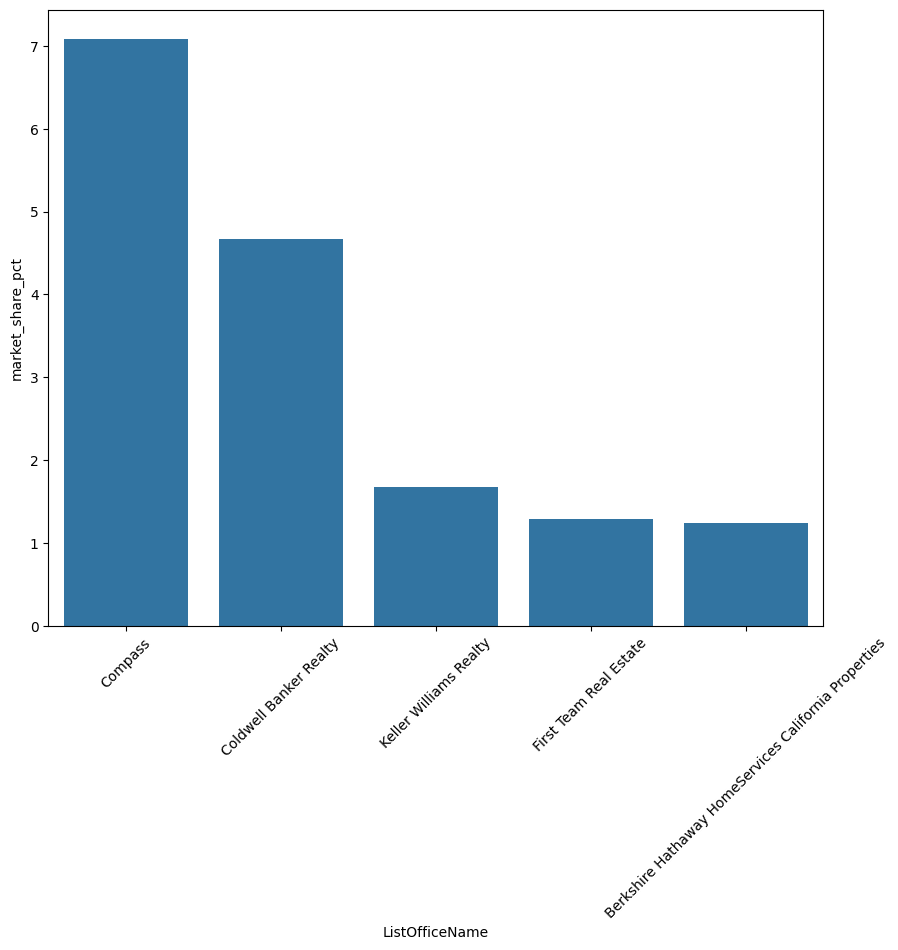

In [130]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='market_share_pct', data=largest_market)
plt.xticks(rotation=45)
plt.show()

B. Premium vs. Discount

In [131]:
listing_office_summary['premium_discount_pct'] = (
    (listing_office_summary['avg_sale_to_list'] - 1) * 100
)

In [132]:
listing_office_summary[listing_office_summary['premium_discount_pct'] < 0].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
10,Sotheby's International Realty,1416,5478,1.510385e+09,755500.0,22.558415,0.982126,12.0,755500.0,1.510385e+09,0.620307,-1.787447
12,Pacific Sotheby's Int'l Realty,846,2974,1.464604e+09,1215000.0,17.147949,0.992429,9.0,1215000.0,1.464604e+09,0.370607,-0.757104
16,Carolwood Estates,401,1889,1.019060e+09,55000.0,20.661726,0.961196,10.0,55000.0,1.019060e+09,0.175666,-3.880373
20,Redfin Corporation,951,3935,8.546784e+08,780000.0,17.896315,0.992408,11.0,780000.0,8.546784e+08,0.416605,-0.759247
25,Seven Gables Real Estate,966,2685,7.525797e+08,732000.0,15.741899,0.996405,10.0,732000.0,7.525797e+08,0.423176,-0.359519


In [133]:
listing_office_summary[listing_office_summary['premium_discount_pct'] > 0].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
0,Compass,16172,53935,2.097741e+10,945000.0,17.961695,1.124340,10.0,945000.0,2.097741e+10,7.084469,12.434002
1,Coldwell Banker Realty,10670,35487,1.106701e+10,790000.0,19.151013,1.296798,10.0,790000.0,1.106701e+10,4.674207,29.679839
2,Keller Williams Realty,3832,12442,3.121868e+09,750000.0,16.766034,2.039065,9.0,750000.0,3.121868e+09,1.678684,103.906499
3,Berkshire Hathaway HomeServices California Pro...,2828,10459,2.939246e+09,655500.0,20.219046,1.331268,11.0,655500.0,2.939246e+09,1.238862,33.126798
4,Intero Real Estate Services,1809,7011,2.827360e+09,1350000.0,17.210669,7.232980,10.0,1350000.0,2.827360e+09,0.792469,623.298006


In [134]:
largest_premium = listing_office_summary[listing_office_summary['premium_discount_pct'] != float('inf')].nlargest(5, 'premium_discount_pct')

In [135]:
largest_premium

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
5769,Conolan Realty,3,5,2138000.0,805000.0,21.200000,297879.319692,17.0,805000.0,2138000.0,0.001314,2.978783e+07
147,Realty Masters & Associates,249,1097,135949839.0,560000.0,18.201459,3849.718354,11.0,560000.0,135949839.0,0.109079,3.848718e+05
37,KW Advisors East Bay,458,1443,522267890.0,958500.0,17.618850,2162.667446,13.0,958500.0,522267890.0,0.200636,2.161667e+05
7504,Dynamic Real Estate Services,1,6,1400000.0,1400000.0,21.333333,1098.039216,21.0,1400000.0,1400000.0,0.000438,1.097039e+05
22,Success Realty & Mortgage,1,1,820000000.0,820000000.0,6.000000,1012.345679,6.0,820000000.0,820000000.0,0.000438,1.011346e+05


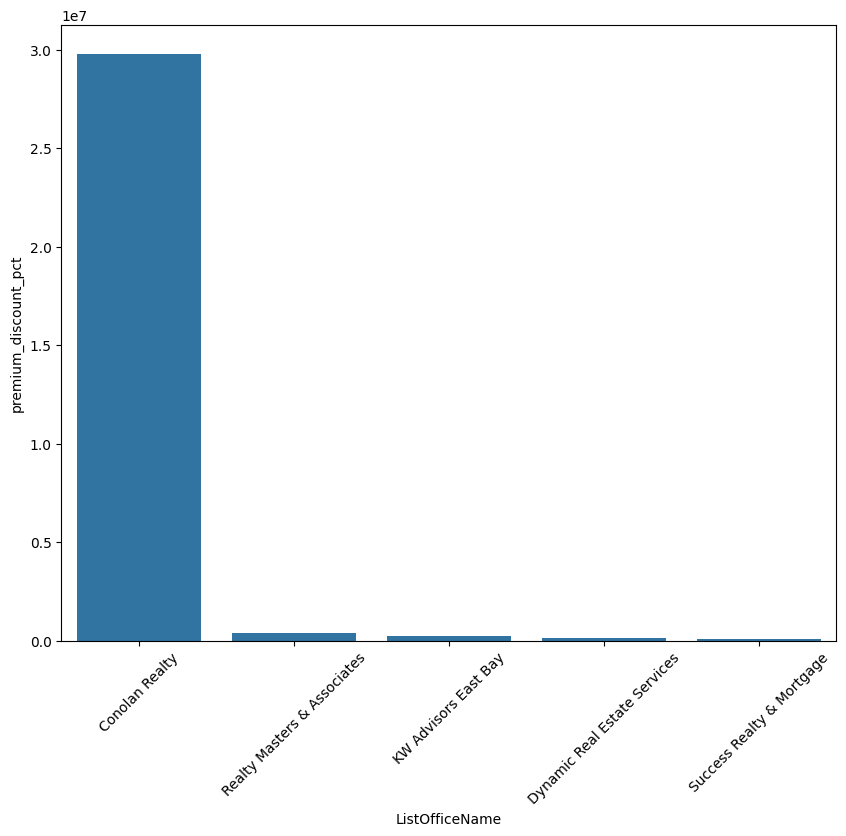

In [136]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='premium_discount_pct', data=largest_premium)
plt.xticks(rotation=45)
plt.show()

In [137]:
smallest_premium = listing_office_summary.nsmallest(5, 'premium_discount_pct')
smallest_premium

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
18094,Elite Realty Agents,1,1,0.00,0.00,1.000000,0.000000,1.0,0.00,0.00,0.000438,-100.000000
15501,"Carl Reinhart, Broker",1,8,18.00,18.00,19.375000,0.000162,13.0,18.00,18.00,0.000438,-99.983772
15502,Altman Apartments LLC,1,9,2.12,2.12,19.666667,0.000356,0.0,2.12,2.12,0.000438,-99.964370
8592,Mayer Makabe,1,3,1100000.00,1100000.00,31.333333,0.000845,15.0,1100000.00,1100000.00,0.000438,-99.915515
15332,Mitigation Land Specialists,1,2,2400.00,2400.00,28.500000,0.000873,28.5,2400.00,2400.00,0.000438,-99.912727


C. Efficiency Score

In [138]:
listing_office_summary['efficiency_score'] = (
    listing_office_summary['avg_sale_to_list']
    / listing_office_summary['median_dom']
)

In [139]:
listing_office_summary[listing_office_summary['efficiency_score'] != float('inf')]['efficiency_score'].describe()

count    15341.000000
mean         1.420282
std        141.535763
min          0.000000
25%          0.064162
50%          0.093444
75%          0.133406
max      17522.312923
Name: efficiency_score, dtype: float64

In [140]:
top_efficiency = (
    listing_office_summary.sort_values(
        by='efficiency_score',
        ascending=False
    )
)

top_efficiency[top_efficiency['efficiency_score'] != float('inf')].nlargest(5, 'efficiency_score')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct,efficiency_score
5769,Conolan Realty,3,5,2138000.0,805000.0,21.200000,297879.319692,17.0,805000.0,2138000.0,0.001314,2.978783e+07,17522.312923
147,Realty Masters & Associates,249,1097,135949839.0,560000.0,18.201459,3849.718354,11.0,560000.0,135949839.0,0.109079,3.848718e+05,349.974396
1440,Woodbridge Coastal Properties,5,7,12401000.0,925000.0,13.000000,882.687859,5.0,925000.0,12401000.0,0.002190,8.816879e+04,176.537572
22,Success Realty & Mortgage,1,1,820000000.0,820000000.0,6.000000,1012.345679,6.0,820000000.0,820000000.0,0.000438,1.011346e+05,168.724280
37,KW Advisors East Bay,458,1443,522267890.0,958500.0,17.618850,2162.667446,13.0,958500.0,522267890.0,0.200636,2.161667e+05,166.359034


D. Luxury Brokerage

In [141]:
# Define luxury threshold (top 10%)

luxury_threshold = (
    listings_cleaned_df['ClosePrice']
    .quantile(0.90)
)
luxury_threshold

np.float64(1715000.0)

In [142]:
# Filter luxury listings

luxury_listings = listings_cleaned_df[
    listings_cleaned_df['ClosePrice'] >= luxury_threshold
]
len(luxury_listings)

22872

In [143]:
luxury_office_summary = (
    luxury_listings.groupby('ListOfficeName')
    .agg(
        luxury_sales=('ClosePrice', 'count'),

        avg_luxury_price=('ClosePrice', 'mean'),

        median_luxury_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

In [144]:
luxury_office_summary

,ListOfficeName,luxury_sales,avg_luxury_price,median_luxury_dom
0,1% LISTING FEE,1,2.390000e+06,35.0
1,10-8 Real Estate,1,2.200000e+06,7.0
2,1000 Realty Corporation,1,2.800000e+06,27.0
3,101 Realty Services,1,5.558888e+06,17.0
4,121 Properties Inc,1,2.500000e+06,1.0
...,...,...,...,...
2952,"eXp Realty of Southern California, Inc.",49,2.430824e+06,9.0
2953,eXp realty of Greater Los Angeles,1,2.875000e+06,7.0
2954,house333,1,2.400000e+06,3.0
2955,iPro Real Estate,2,2.405000e+06,3.0


In [145]:
# Keep offices with enough luxury transactions

luxury_office_summary = luxury_office_summary[
    luxury_office_summary['luxury_sales'] >= 5
]

print("\nTOP LUXURY OFFICES")
print(
    luxury_office_summary.sort_values(
        by='luxury_sales',
        ascending=False
    ).head(10)
)


TOP LUXURY OFFICES
                                         ListOfficeName  luxury_sales  \
631                                             Compass          4097   
615                              Coldwell Banker Realty          2015   
1215                        Intero Real Estate Services           597   
2586                                         The Agency           553   
294   Berkshire Hathaway HomeServices California Pro...           506   
556         Christie's International Real Estate Sereno           346   
2458                     Sotheby's International Realty           308   
1376                             Keller Williams Realty           295   
1868                     Pacific Sotheby's Int'l Realty           288   
2155                                        Real Broker           231   

      avg_luxury_price  median_luxury_dom  
631       3.236874e+06                9.0  
615       3.007229e+06                8.0  
1215      2.768960e+06                7.0  


In [146]:
largest_luxury = luxury_office_summary.nlargest(5, 'luxury_sales')

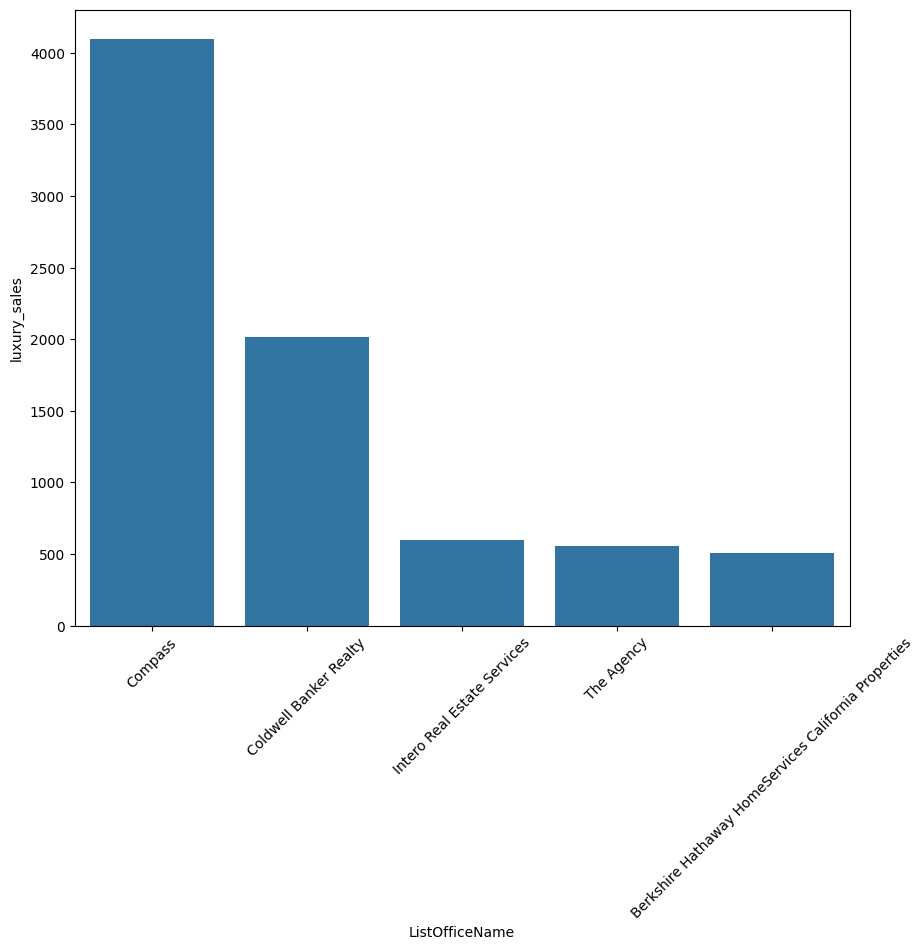

In [147]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='luxury_sales', data=largest_luxury)
plt.xticks(rotation=45)
plt.show()

E. Geographic Specialization

In [148]:
office_geo_summary = (
    listings_cleaned_df.groupby(
        ['ListOfficeName', 'MLSAreaMajor']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE GEOGRAPHIC SPECIALIZATION")
print(office_geo_summary.head())


OFFICE GEOGRAPHIC SPECIALIZATION
               ListOfficeName                        MLSAreaMajor  \
0  #1 FLAT FEE-LIBERTY REALTY                   682 - Chino Hills   
1           #1 Home SalesÃÂ®                     252 - Riverside   
2           #1 Home SalesÃÂ®  SRCAR - Southwest Riverside County   
3        #1 Realty Homes Inc.             322 - North Palm Desert   
4        #1 Realty Homes Inc.          335 - Cathedral City North   

   sales_count  avg_close_price  median_dom  
0            1         945000.0        16.0  
1            0              NaN        16.0  
2            0              NaN         2.0  
3            0              NaN         2.0  
4            0              NaN        53.5  


In [149]:
office_geo_summary.nlargest(5, 'avg_close_price')

,ListOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
154784,Success Realty & Mortgage,89 - Tustin Ranch,1,820000000.0,6.0
18883,Blue Diamond Sales & Rentals,92056 - Oceanside,1,576000000.0,7.0
38260,Coldwell Banker West,VIC - Victorville,2,236001500.0,63.5
15413,Berkshire Hathaway HomeService,92019 - El Cajon,4,144080500.0,10.0
8872,Apartment Realty Group (ARG),92113 - Logan Heights,1,117500000.0,8.0


In [150]:
office_geo_summary.nlargest(5, 'sales_count')

,ListOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
39296,Compass,Missing,2868,1.381519e+06,10.0
38954,Compass,699 - Not Defined,2232,1.954466e+06,10.0
37120,Coldwell Banker Realty,699 - Not Defined,2006,1.757187e+06,10.0
74193,Intero Real Estate Services,699 - Not Defined,1369,1.696822e+06,10.0
37426,Coldwell Banker Realty,Missing,925,1.277715e+06,9.0


F. Property Type Specialization

In [151]:
office_property_summary = (
    listings_cleaned_df.groupby(
        ['ListOfficeName', 'PropertyType']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE PROPERTY TYPE SPECIALIZATION")
print(office_property_summary.head())


OFFICE PROPERTY TYPE SPECIALIZATION
               ListOfficeName        PropertyType  sales_count  \
0  #1 FLAT FEE-LIBERTY REALTY         Residential            1   
1           #1 Home SalesÃÂ®         Residential            0   
2        #1 Realty Homes Inc.         Residential            0   
3        #1 Realty Homes Inc.    ResidentialLease            0   
4                           *  ManufacturedInPark            0   

   avg_close_price  median_dom  
0         945000.0        16.0  
1              NaN         3.0  
2              NaN         5.0  
3              NaN         8.0  
4              NaN         1.5  


In [152]:
office_property_summary.nlargest(5, 'avg_close_price')

,ListOfficeName,PropertyType,sales_count,avg_close_price,median_dom
39933,Success Realty & Mortgage,Residential,1,8.200000e+08,6.0
5338,Blue Diamond Sales & Rentals,Residential,3,1.922850e+08,3.5
23717,Land Co Development Inc,Residential,1,3.800000e+07,7.5
29102,ORES Realty,Residential,1,2.700000e+07,2.5
2709,Apartment Realty Group (ARG),CommercialSale,7,1.974214e+07,3.5


In [153]:
office_property_summary.nlargest(5, 'sales_count')

,ListOfficeName,PropertyType,sales_count,avg_close_price,median_dom
9916,Compass,Residential,11220,1.797652e+06,11.0
9658,Coldwell Banker Realty,Residential,6790,1.557740e+06,11.0
9918,Compass,ResidentialLease,4426,8.589656e+03,9.0
9660,Coldwell Banker Realty,ResidentialLease,3483,1.027675e+04,10.0
22275,Keller Williams Realty,Residential,2832,1.039254e+06,9.0


G. Office Tier Classification

In [154]:
def classify_office(row):

    if row['sales_count'] > 500:
        return 'High Volume'

    elif row['median_close_price'] > 1000000:
        return 'Luxury Specialist'

    elif row['efficiency_score'] > 0.02:
        return 'High Efficiency'

    else:
        return 'Standard'


listing_office_summary['office_category'] = (
    listing_office_summary.apply(classify_office, axis=1)
)

print("\nOFFICE CATEGORIES")
print(
    listing_office_summary[
        ['ListOfficeName', 'office_category']
    ].head(20)
)


OFFICE CATEGORIES
                                       ListOfficeName  office_category
0                                             Compass      High Volume
1                              Coldwell Banker Realty      High Volume
2                              Keller Williams Realty      High Volume
3   Berkshire Hathaway HomeServices California Pro...      High Volume
4                         Intero Real Estate Services      High Volume
5                                Coldwell Banker West      High Volume
6                                          The Agency      High Volume
7                              First Team Real Estate      High Volume
8                                         Real Broker      High Volume
9                        eXp Realty of California Inc      High Volume
10                     Sotheby's International Realty      High Volume
11        Christie's International Real Estate Sereno      High Volume
12                     Pacific Sotheby's Int'l Realty     

H. Competitive Positioning

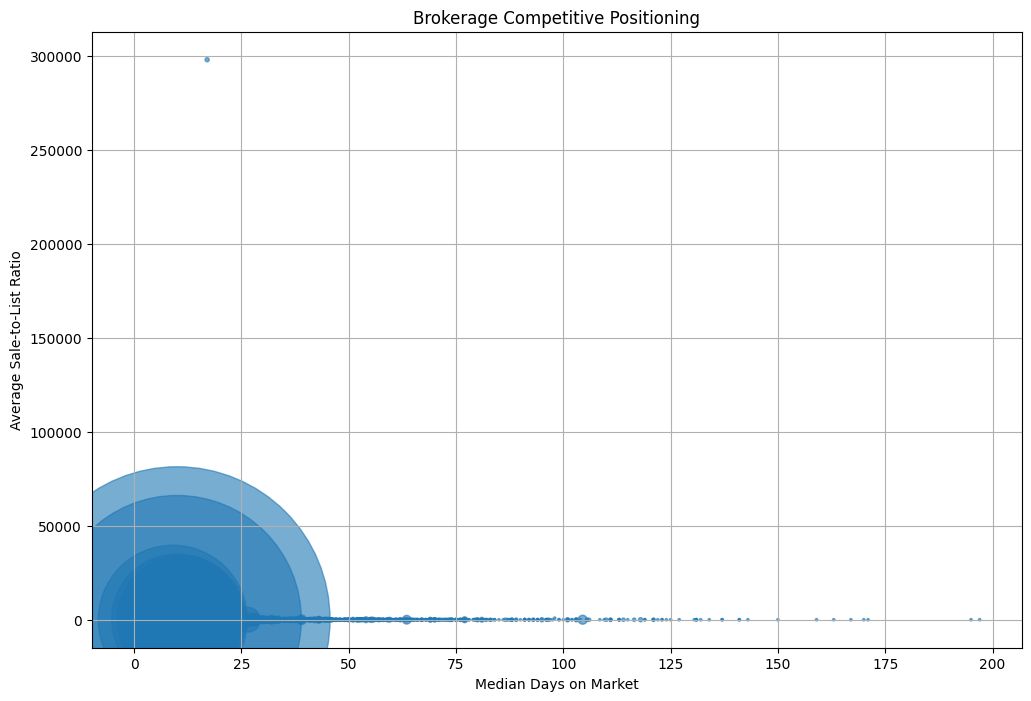

In [155]:
plt.figure(figsize=(12, 8))

plt.scatter(
    listing_office_summary['median_dom'],
    listing_office_summary['avg_sale_to_list'],

    s=listing_office_summary['sales_count'] * 3,

    alpha=0.6
)

plt.xlabel('Median Days on Market')
plt.ylabel('Average Sale-to-List Ratio')

plt.title('Brokerage Competitive Positioning')

plt.grid(True)

plt.show()

I. Top 10 Offices by Sales Volume

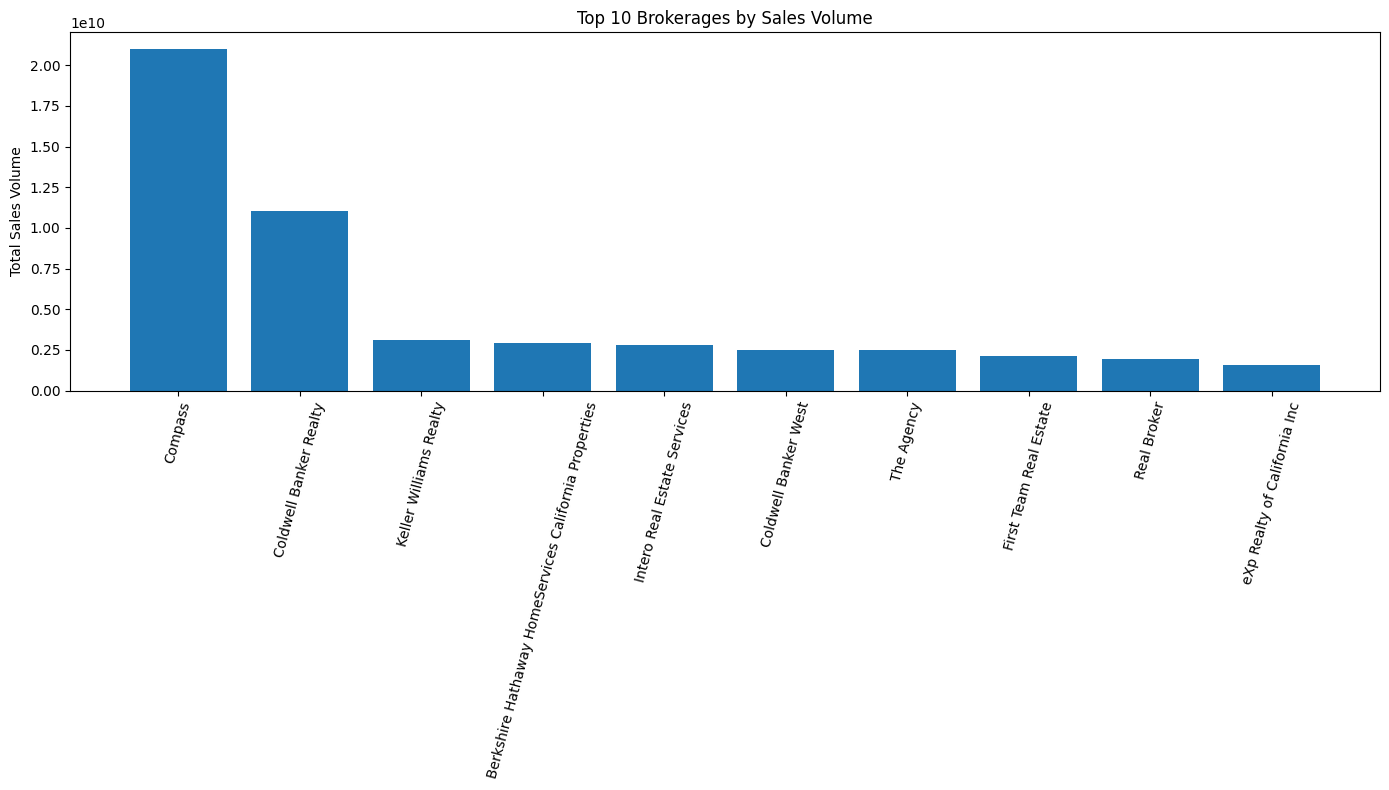

In [156]:
top_volume = (
    listing_office_summary.sort_values(
        by='total_sales_volume',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(14, 8))

plt.bar(
    top_volume['ListOfficeName'],
    top_volume['total_sales_volume']
)

plt.xticks(rotation=75)

plt.ylabel('Total Sales Volume')

plt.title('Top 10 Brokerages by Sales Volume')

plt.tight_layout()

plt.show()

BuyerOfficeName

In [157]:
buyer_office_summary = (
    listings_cleaned_df.groupby('BuyerOfficeName')
    .agg(
        listings=('ListingId', 'count'),
        total_volume=('ClosePrice', 'sum'),
        median_sale_price=('ClosePrice', 'median'),
        avg_dom=('DaysOnMarket', 'mean'),
        avg_sale_to_list=('price_ratio', 'mean'),
        sales_count=('ClosePrice', 'count'),
        median_dom=('DaysOnMarket', 'median'),
        median_close_price=('ClosePrice', 'median'),
        total_sales_volume=('ClosePrice', 'sum')
    )
    .sort_values('total_volume', ascending=False)
    .reset_index()
)

In [158]:
buyer_office_summary[buyer_office_summary.notna()].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume
0,Compass,17055,1.989950e+10,935000.0,21.000997,2.105091,15412,12.0,935000.0,1.989950e+10
1,Coldwell Banker Realty,9542,8.960838e+09,715000.0,22.118005,1.328792,9041,12.0,715000.0,8.960838e+09
2,Keller Williams Realty,3662,3.060799e+09,683250.0,20.584107,2.200592,3246,11.0,683250.0,3.060799e+09
3,Real Broker,3143,2.875947e+09,699000.0,24.668788,2.720710,3050,14.0,699000.0,2.875947e+09
4,Intero Real Estate Services,1982,2.260341e+09,1310000.0,16.032795,1.038748,1499,9.0,1310000.0,2.260341e+09


A. Brokerage Performance

In [159]:
buyer_office_summary['avg_sale_to_list'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.623800e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.678875e-01
50%      9.935203e-01
75%      1.009023e+00
max               inf
Name: avg_sale_to_list, dtype: float64

In [160]:
buyer_office_summary[buyer_office_summary['avg_sale_to_list'] != float('inf')].nlargest(10, 'avg_sale_to_list')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume
7576,Sonnek Realty,5,1.526350e+06,4750.0,14.400000,120000.792547,5,16.0,4750.0,1.526350e+06
1149,REALTY ONE GROUP HOMELINK,29,1.554895e+07,560000.0,26.758621,34483.709255,29,17.0,560000.0,1.554895e+07
132,Christie's AKG,116,1.588927e+08,698000.0,19.931034,7771.731347,115,14.0,698000.0,1.588927e+08
144,Realty Masters & Associates,247,1.485866e+08,564900.0,23.105263,3880.927158,247,13.0,564900.0,1.485866e+08
49,KW Advisors East Bay,620,4.193682e+08,1065000.0,18.072581,2808.736145,353,13.0,1065000.0,4.193682e+08
7634,GOLDEN INFINITY GROUP,2,1.509500e+06,754750.0,10.500000,1575.460251,2,10.5,754750.0,1.509500e+06
1533,Woodbridge Coastal Properties,4,1.125100e+07,552500.0,7.750000,1103.129763,4,6.5,552500.0,1.125100e+07
10384,Pickford Real Estate Inc,1,8.400000e+05,840000.0,21.000000,1001.191895,1,21.0,840000.0,8.400000e+05
5945,"Thompson Team Real Estate, Inc",1,2.250000e+06,2250000.0,20.000000,1000.000000,1,20.0,2250000.0,2.250000e+06
11404,"Equinox Real Estate Group, Inc.",1,6.800000e+05,680000.0,0.000000,1000.000000,1,0.0,680000.0,6.800000e+05


In [161]:
buyer_office_summary['market_share_pct'] = (
    buyer_office_summary['sales_count']
    / buyer_office_summary['sales_count'].sum()
) * 100

In [162]:
avg_market = buyer_office_summary.groupby('BuyerOfficeName')['market_share_pct'].mean().reset_index()
avg_market.head()

,BuyerOfficeName,market_share_pct
0,& Company Real Estate,0.000443
1,*,0.001328
2,", Inc",0.000443
3,1,0.000443
4,1 Percent Lists Desert 2 Coast,0.000443


In [163]:
buyer_office_summary.nlargest(5, 'market_share_pct')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct
0,Compass,17055,1.989950e+10,935000.0,21.000997,2.105091,15412,12.0,935000.0,1.989950e+10,6.820465
1,Coldwell Banker Realty,9542,8.960838e+09,715000.0,22.118005,1.328792,9041,12.0,715000.0,8.960838e+09,4.001027
23,None MRML,4853,7.714251e+08,3900.0,25.893674,1.196263,4853,16.0,3900.0,7.714251e+08,2.147659
8,NONMEMBER MRML,4191,1.979195e+09,400000.0,28.811978,inf,4158,17.0,400000.0,1.979195e+09,1.840092
2,Keller Williams Realty,3662,3.060799e+09,683250.0,20.584107,2.200592,3246,11.0,683250.0,3.060799e+09,1.436493


In [164]:
largest_market = avg_market.nlargest(5, 'market_share_pct')
largest_market

,BuyerOfficeName,market_share_pct
3599,Compass,6.820465
3511,Coldwell Banker Realty,4.001027
10311,None MRML,2.147659
9954,NONMEMBER MRML,1.840092
7954,Keller Williams Realty,1.436493


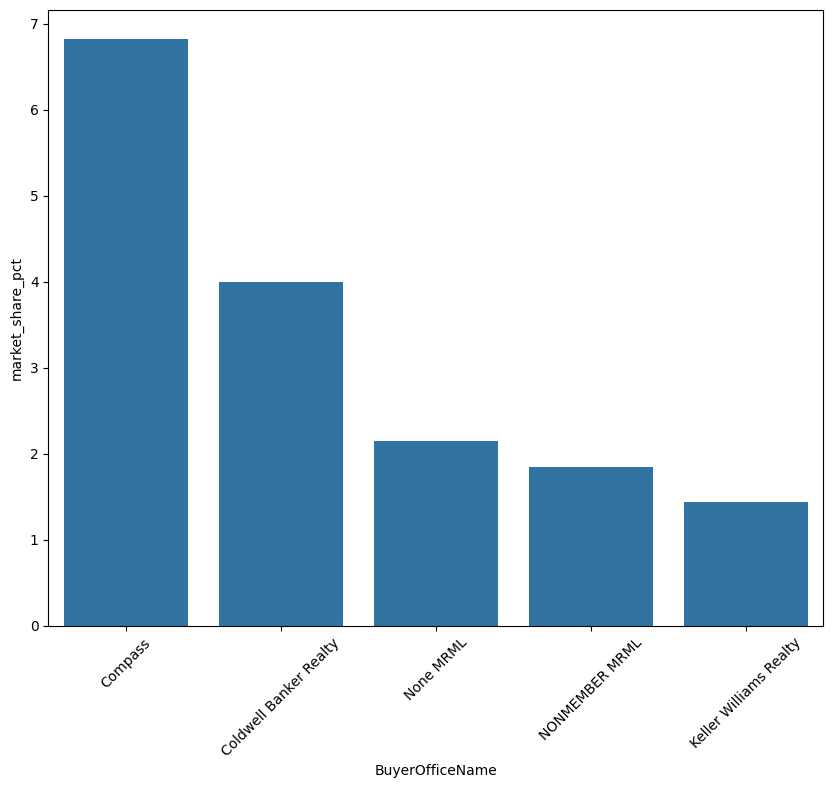

In [165]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='market_share_pct', data=largest_market)
plt.xticks(rotation=45)
plt.show()

B. Premium vs. Discount

In [166]:
buyer_office_summary['premium_discount_pct'] = (
    (buyer_office_summary['avg_sale_to_list'] - 1) * 100
)

In [167]:
buyer_office_summary[buyer_office_summary['premium_discount_pct'] < 0].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
15,Redfin Corporation,1266,1.223032e+09,849000.0,24.596367,0.995777,1246,13.0,849000.0,1.223032e+09,0.551408,-0.422274
16,Sotheby's International Realty,1300,1.194460e+09,485000.0,26.471538,0.987458,1282,15.0,485000.0,1.194460e+09,0.567339,-1.254162
19,Carolwood Estates,452,1.072004e+09,23500.0,28.307522,0.975690,452,17.0,23500.0,1.072004e+09,0.200029,-2.431020
20,Pacific Sotheby's Int'l Realty,642,1.070755e+09,1045000.0,20.679128,0.986388,642,10.0,1045000.0,1.070755e+09,0.284112,-1.361203
26,Seven Gables Real Estate,855,6.739411e+08,685000.0,19.280702,0.995063,855,11.0,685000.0,6.739411e+08,0.378374,-0.493694


In [168]:
buyer_office_summary[buyer_office_summary['premium_discount_pct'] > 0].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
0,Compass,17055,1.989950e+10,935000.0,21.000997,2.105091,15412,12.0,935000.0,1.989950e+10,6.820465,110.509058
1,Coldwell Banker Realty,9542,8.960838e+09,715000.0,22.118005,1.328792,9041,12.0,715000.0,8.960838e+09,4.001027,32.879248
2,Keller Williams Realty,3662,3.060799e+09,683250.0,20.584107,2.200592,3246,11.0,683250.0,3.060799e+09,1.436493,120.059164
3,Real Broker,3143,2.875947e+09,699000.0,24.668788,2.720710,3050,14.0,699000.0,2.875947e+09,1.349755,172.071025
4,Intero Real Estate Services,1982,2.260341e+09,1310000.0,16.032795,1.038748,1499,9.0,1310000.0,2.260341e+09,0.663371,3.874751


In [169]:
largest_premium = buyer_office_summary[buyer_office_summary['premium_discount_pct'] != float('inf')].nlargest(5, 'premium_discount_pct')
largest_premium

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
7576,Sonnek Realty,5,1.526350e+06,4750.0,14.400000,120000.792547,5,16.0,4750.0,1.526350e+06,0.002213,1.199998e+07
1149,REALTY ONE GROUP HOMELINK,29,1.554895e+07,560000.0,26.758621,34483.709255,29,17.0,560000.0,1.554895e+07,0.012834,3.448271e+06
132,Christie's AKG,116,1.588927e+08,698000.0,19.931034,7771.731347,115,14.0,698000.0,1.588927e+08,0.050892,7.770731e+05
144,Realty Masters & Associates,247,1.485866e+08,564900.0,23.105263,3880.927158,247,13.0,564900.0,1.485866e+08,0.109308,3.879927e+05
49,KW Advisors East Bay,620,4.193682e+08,1065000.0,18.072581,2808.736145,353,13.0,1065000.0,4.193682e+08,0.156218,2.807736e+05


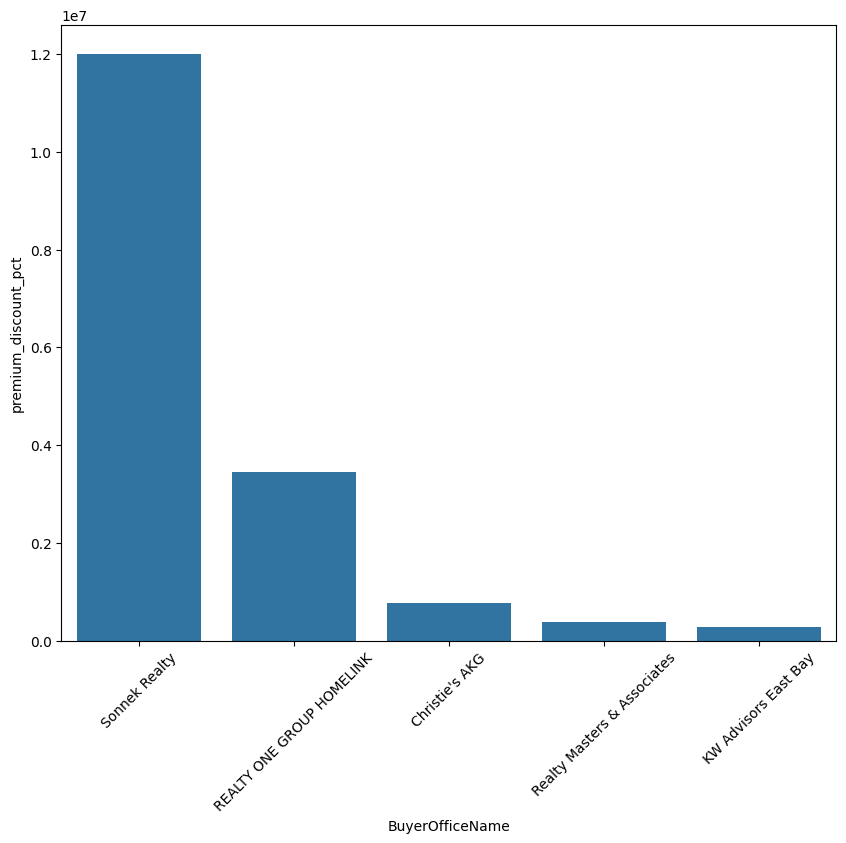

In [170]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='premium_discount_pct', data=largest_premium)
plt.xticks(rotation=45)
plt.show()

In [171]:
smallest_premium = buyer_office_summary.nsmallest(5, 'premium_discount_pct')
smallest_premium

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
16415,C21 Realty Masters,1,0.00,0.00,25.0,0.000000,1,25.0,0.00,0.00,0.000443,-100.000000
16493,Elite Realty Agents,1,0.00,0.00,1.0,0.000000,1,1.0,0.00,0.00,0.000443,-100.000000
16235,Altman Apartments LLC,1,2.12,2.12,96.0,0.000356,1,96.0,2.12,2.12,0.000443,-99.964370
16044,Mitigation Land Specialists,1,2400.00,2400.00,57.0,0.000873,1,57.0,2400.00,2400.00,0.000443,-99.912727
15879,"Scott Voak, Broker",1,2900.00,2900.00,44.0,0.000906,1,44.0,2900.00,2900.00,0.000443,-99.909375


C. Efficiency Score

In [172]:
buyer_office_summary['efficiency_score'] = (
    buyer_office_summary['avg_sale_to_list']
    / buyer_office_summary['median_dom']
)

In [173]:
buyer_office_summary[buyer_office_summary['efficiency_score'] != float('inf')]['efficiency_score'].describe()

count    15855.000000
mean         0.834319
std         61.964579
min          0.000000
25%          0.037109
50%          0.068563
75%          0.114980
max       7500.049534
Name: efficiency_score, dtype: float64

In [174]:
top_efficiency = (
    buyer_office_summary.sort_values(
        by='efficiency_score',
        ascending=False
    )
)


In [175]:
top_efficiency[top_efficiency['efficiency_score'] != float('inf')].nlargest(5, 'efficiency_score')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct,efficiency_score
7576,Sonnek Realty,5,1.526350e+06,4750.0,14.400000,120000.792547,5,16.0,4750.0,1.526350e+06,0.002213,1.199998e+07,7500.049534
1149,REALTY ONE GROUP HOMELINK,29,1.554895e+07,560000.0,26.758621,34483.709255,29,17.0,560000.0,1.554895e+07,0.012834,3.448271e+06,2028.453486
132,Christie's AKG,116,1.588927e+08,698000.0,19.931034,7771.731347,115,14.0,698000.0,1.588927e+08,0.050892,7.770731e+05,555.123668
144,Realty Masters & Associates,247,1.485866e+08,564900.0,23.105263,3880.927158,247,13.0,564900.0,1.485866e+08,0.109308,3.879927e+05,298.532858
49,KW Advisors East Bay,620,4.193682e+08,1065000.0,18.072581,2808.736145,353,13.0,1065000.0,4.193682e+08,0.156218,2.807736e+05,216.056627


D. Luxury Brokerage

In [176]:
# Define luxury threshold (top 10%)

luxury_threshold = (
    listings_cleaned_df['ClosePrice']
    .quantile(0.90)
)
luxury_threshold


np.float64(1715000.0)

In [177]:
# Filter luxury listings

luxury_listings = listings_cleaned_df[
    listings_cleaned_df['ClosePrice'] >= luxury_threshold
]
len(luxury_listings)

luxury_office_summary = (
    luxury_listings.groupby('BuyerOfficeName')
    .agg(
        luxury_sales=('ClosePrice', 'count'),

        avg_luxury_price=('ClosePrice', 'mean'),

        median_luxury_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

luxury_office_summary

,BuyerOfficeName,luxury_sales,avg_luxury_price,median_luxury_dom
0,", Inc",1,2225000.0,4.0
1,1 Percent Lists SoCal,1,2325000.0,6.0
2,1000 Realty Corporation,1,2800000.0,27.0
3,1031 Exchange Group,1,2138000.0,10.0
4,168 Realty,3,2299378.0,8.0
...,...,...,...,...
3461,house333,1,2400000.0,3.0
3462,iHome Realty,2,2100000.0,20.5
3463,iResidential Real Estate,1,2300000.0,2.0
3464,kw pacific estates,1,2368880.0,18.0


In [178]:
# Keep offices with enough luxury transactions

luxury_office_summary = luxury_office_summary[
    luxury_office_summary['luxury_sales'] >= 5
]

print("\nTOP LUXURY OFFICES")
print(
    luxury_office_summary.sort_values(
        by='luxury_sales',
        ascending=False
    ).head(10)
)


TOP LUXURY OFFICES
                                        BuyerOfficeName  luxury_sales  \
716                                             Compass          3768   
696                              Coldwell Banker Realty          1629   
1410                        Intero Real Estate Services           466   
3038                                         The Agency           443   
348   Berkshire Hathaway HomeServices California Pro...           386   
1605                             Keller Williams Realty           260   
2504                                        Real Broker           251   
2602                                             Redfin           244   
622         Christie's International Real Estate Sereno           235   
2894                     Sotheby's International Realty           224   

      avg_luxury_price  median_luxury_dom  
716       3.333606e+06                9.0  
696       3.092149e+06                9.0  
1410      2.708202e+06                7.0  


In [179]:
largest_luxury = luxury_office_summary.nlargest(5, 'luxury_sales')

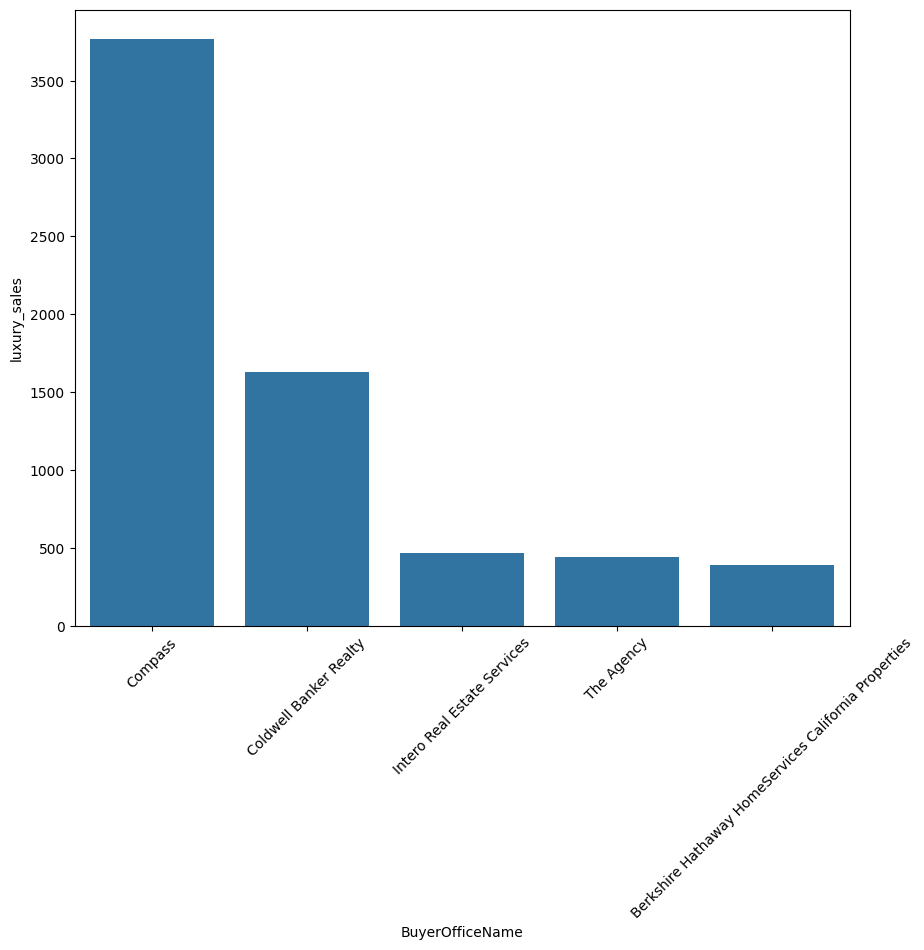

In [180]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='luxury_sales', data=largest_luxury)
plt.xticks(rotation=45)
plt.show()

E. Geographic Specialization

In [181]:
office_geo_summary = (
    listings_cleaned_df.groupby(
        ['BuyerOfficeName', 'MLSAreaMajor']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE GEOGRAPHIC SPECIALIZATION")
print(office_geo_summary.head())


OFFICE GEOGRAPHIC SPECIALIZATION
         BuyerOfficeName                           MLSAreaMajor  sales_count  \
0  & Company Real Estate                       AV - Aliso Viejo            1   
1                      *  6 - Bixby, Bixby Knolls, Los Cerritos            1   
2                      *                      699 - Not Defined            1   
3                      *                   7 - North Long Beach            1   
4                  , Inc          NV - East Bluff - Harbor View            1   

   avg_close_price  median_dom  
0           3500.0         6.0  
1         730000.0         6.0  
2         865000.0        85.0  
3           3500.0        15.0  
4        2225000.0         4.0  


In [182]:
office_geo_summary.nlargest(5, 'avg_close_price')

,BuyerOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
76988,United Real Estate San Diego,92019 - El Cajon,2,2.747525e+08,12.0
3762,Apartment Realty Group (ARG),92113 - Logan Heights,1,1.175000e+08,15.0
1620,Abundance Real Estate,92028 - Fallbrook,5,8.503900e+07,15.0
63810,Realty One Group West,89 - Tustin Ranch,15,5.521299e+07,9.0
47998,Newmark Residential,C32 - Malibu Beach,1,3.845000e+07,49.0


In [183]:
office_geo_summary.nlargest(5, 'sales_count')

,BuyerOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
18051,Compass,Missing,2442,1.400845e+06,11.0
17795,Compass,699 - Not Defined,1823,1.974186e+06,8.0
16670,Coldwell Banker Realty,699 - Not Defined,1473,1.754601e+06,8.0
32907,Intero Real Estate Services,699 - Not Defined,975,1.634798e+06,8.0
46871,NONMEMBER MRML,Missing,883,4.528462e+05,15.0


F. Property Type Specialization

In [184]:
office_property_summary = (
    listings_cleaned_df.groupby(
        ['BuyerOfficeName', 'PropertyType']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)
print("\nOFFICE PROPERTY TYPE SPECIALIZATION")
print(office_property_summary.head())


OFFICE PROPERTY TYPE SPECIALIZATION
         BuyerOfficeName      PropertyType  sales_count  avg_close_price  \
0  & Company Real Estate  ResidentialLease            1           3500.0   
1                      *       Residential            2         797500.0   
2                      *  ResidentialLease            1           3500.0   
3                  , Inc       Residential            1        2225000.0   
4                      1       Residential            1         895000.0   

   median_dom  
0         6.0  
1        45.5  
2        15.0  
3         4.0  
4        12.0  


In [185]:
office_property_summary.nlargest(5, 'avg_close_price')

,BuyerOfficeName,PropertyType,sales_count,avg_close_price,median_dom
1439,Apartment Realty Group (ARG),CommercialSale,3,4.051667e+07,15.0
15744,ORES Realty,Residential,1,2.700000e+07,5.0
23591,US Pacific Realty,Residential,1,2.680000e+07,17.0
7324,Engel & Volkers Carmel,Residential,1,2.575000e+07,173.0
15296,Newmark Residential,Residential,2,2.413500e+07,24.5


In [186]:
office_property_summary.nlargest(5, 'sales_count')

,BuyerOfficeName,PropertyType,sales_count,avg_close_price,median_dom
5483,Compass,Residential,10503,1.827507e+06,10.0
5326,Coldwell Banker Realty,Residential,5394,1.593376e+06,10.0
5485,Compass,ResidentialLease,4446,8.695178e+03,15.0
15551,None MRML,ResidentialLease,3959,6.158266e+03,16.0
5328,Coldwell Banker Realty,ResidentialLease,3343,9.024388e+03,14.5


G. Office Tier Classification

In [187]:
def classify_office(row):

    if row['sales_count'] > 500:
        return 'High Volume'

    elif row['median_close_price'] > 1000000:
        return 'Luxury Specialist'

    elif row['efficiency_score'] > 0.02:
        return 'High Efficiency'

    else:
        return 'Standard'


buyer_office_summary['office_category'] = (
    buyer_office_summary.apply(classify_office, axis=1)
)

print("\nOFFICE CATEGORIES")
print(
    buyer_office_summary[
        ['BuyerOfficeName', 'office_category']
    ].head(20)
)



OFFICE CATEGORIES
                                      BuyerOfficeName  office_category
0                                             Compass      High Volume
1                              Coldwell Banker Realty      High Volume
2                              Keller Williams Realty      High Volume
3                                         Real Broker      High Volume
4                         Intero Real Estate Services      High Volume
5   Berkshire Hathaway HomeServices California Pro...      High Volume
6                                          The Agency      High Volume
7                        eXp Realty of California Inc      High Volume
8                                      NONMEMBER MRML      High Volume
9                              First Team Real Estate      High Volume
10                                             Redfin      High Volume
11                     eXp Realty of California, Inc.      High Volume
12                               Coldwell Banker West     

H. Competitive Positioning

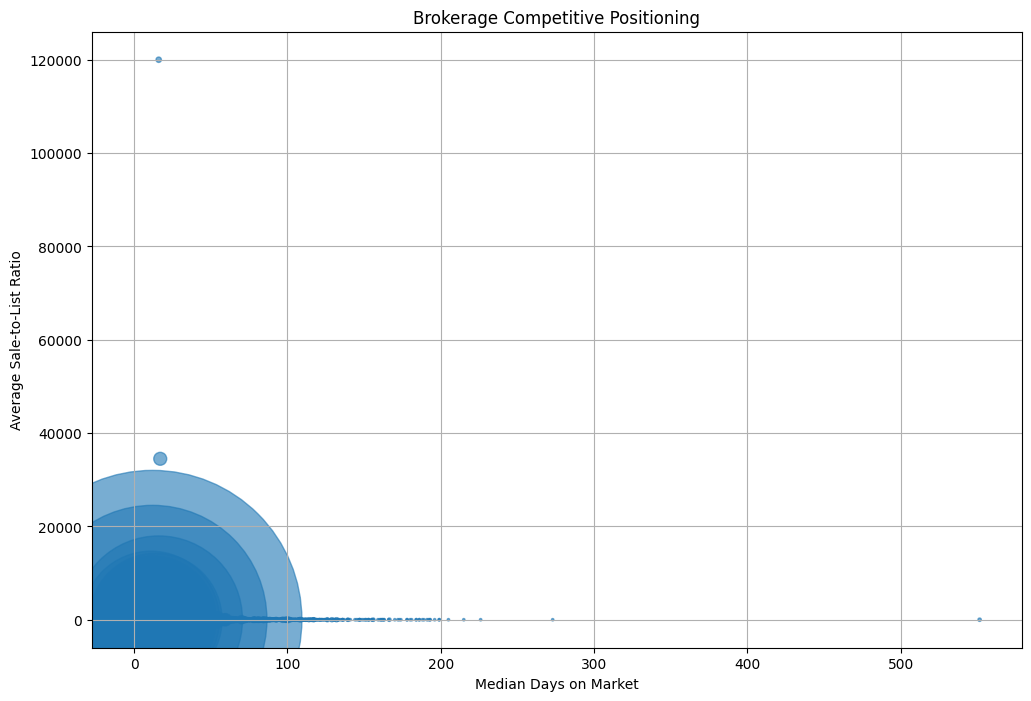

In [188]:
plt.figure(figsize=(12, 8))

plt.scatter(
    buyer_office_summary['median_dom'],
    buyer_office_summary['avg_sale_to_list'],

    s=buyer_office_summary['sales_count'] * 3,

    alpha=0.6
)

plt.xlabel('Median Days on Market')
plt.ylabel('Average Sale-to-List Ratio')

plt.title('Brokerage Competitive Positioning')

plt.grid(True)

plt.show()

I. Top 10 Offices by Sales Volume

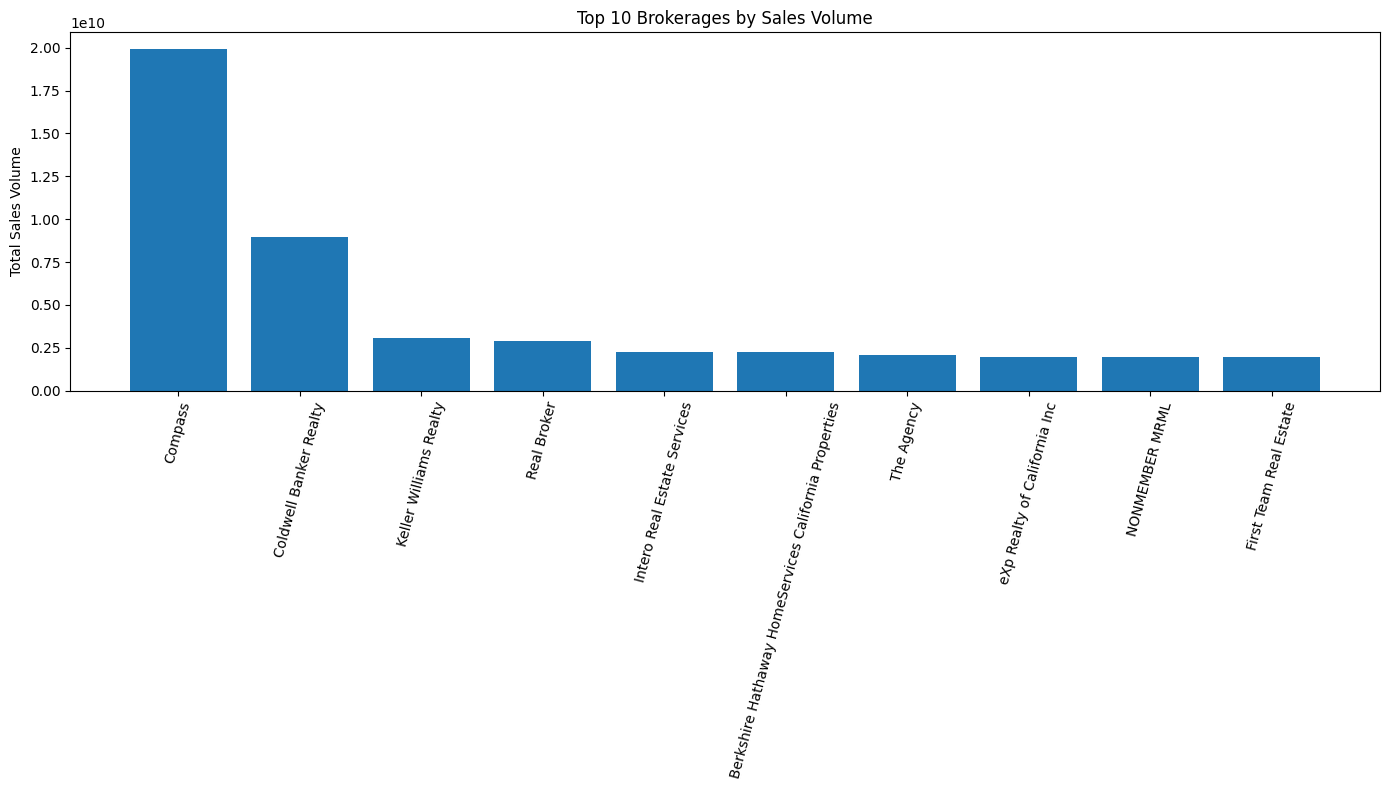

In [189]:
top_volume = (
    buyer_office_summary.sort_values(
        by='total_sales_volume',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(14, 8))

plt.bar(
    top_volume['BuyerOfficeName'],
    top_volume['total_sales_volume']
)

plt.xticks(rotation=75)

plt.ylabel('Total Sales Volume')

plt.title('Top 10 Brokerages by Sales Volume')

plt.tight_layout()

plt.show()

In [190]:
listings_cleaned_df.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'Year', 'missing_coordinates_flag',
       'sentinel_null_flag', 'positive_longitude_flag'

In [191]:
listings_cleaned_df.to_csv("../data/Listing/listings_cleaned_df.csv", index=False)